In [4]:
# Reading the CSV and previewing
import pandas as pd

df = pd.read_csv("Social_Network_Ads.csv")

df.head(), df.shape

(   Age  EstimatedSalary  Purchased
 0   19            19000          0
 1   35            20000          0
 2   26            43000          0
 3   27            57000          0
 4   19            76000          0,
 (400, 3))

In [5]:
df.columns, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


(Index(['Age', 'EstimatedSalary', 'Purchased'], dtype='object'), None)

In [6]:
df[['Age', 'EstimatedSalary']].describe()

,Age,EstimatedSalary
count,400.000000,400.000000
mean,37.655000,69742.500000
std,10.482877,34096.960282
min,18.000000,15000.000000
25%,29.750000,43000.000000
50%,37.000000,70000.000000
75%,46.000000,88000.000000
max,60.000000,150000.000000


In [7]:
# Median
df[['Age', 'EstimatedSalary']].median()

Age                   37.0
EstimatedSalary    70000.0
dtype: float64

In [8]:
# Purchased class distribution
df['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [9]:
# proportional purpose
df['Purchased'].value_counts(normalize=True)

Purchased
0    0.6425
1    0.3575
Name: proportion, dtype: float64

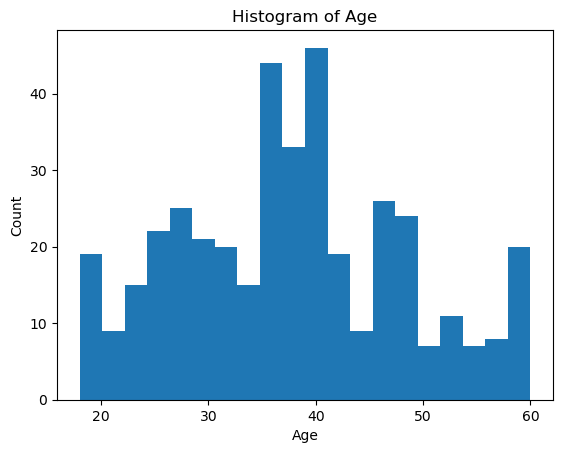

In [10]:
# Visual EDA — Histogram of Age
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['Age'], bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Histogram of Age")
plt.show()

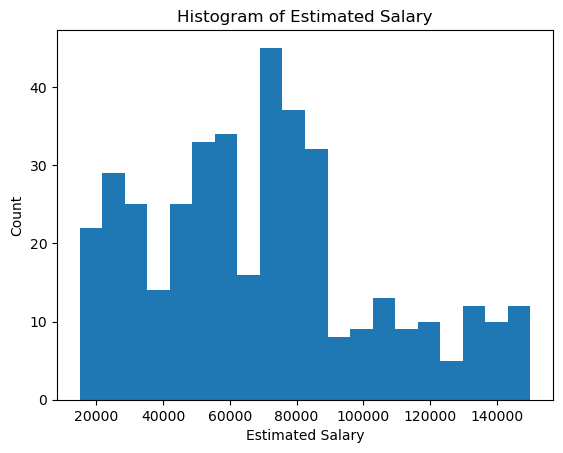

In [11]:
# Visual EDA — Histogram of EstimatedSalary
plt.figure()
plt.hist(df['EstimatedSalary'], bins=20)
plt.xlabel("Estimated Salary")
plt.ylabel("Count")
plt.title("Histogram of Estimated Salary")
plt.show()

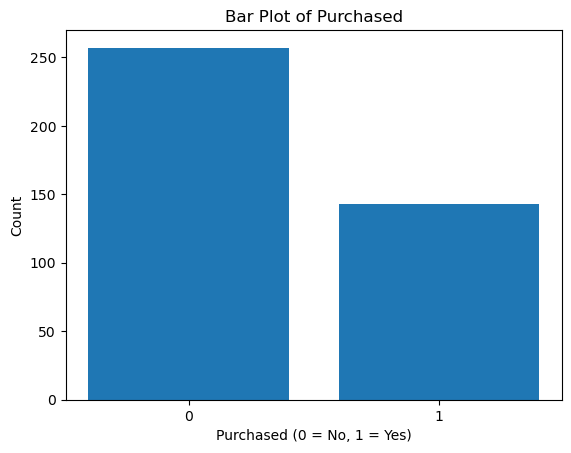

In [12]:
# Bar Plot of Purchased
counts = df['Purchased'].value_counts().sort_index()

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Purchased (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Bar Plot of Purchased")
plt.show()

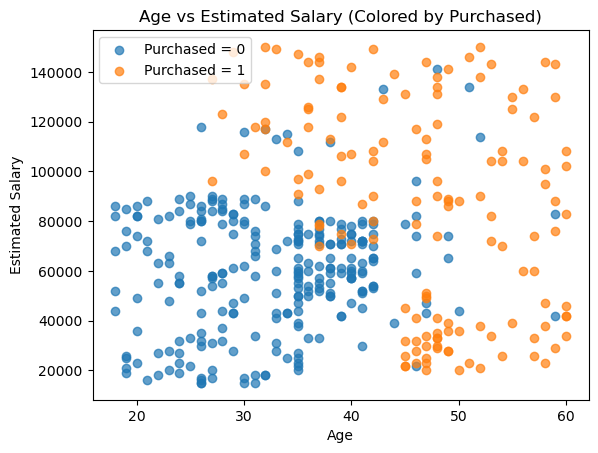

In [13]:
# Scatter Plot — Age vs Estimated Salary
plt.figure()

for val in [0, 1]:
    subset = df[df['Purchased'] == val]
    plt.scatter(
        subset['Age'],
        subset['EstimatedSalary'],
        label=f"Purchased = {val}",
        alpha=0.7
    )

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Age vs Estimated Salary (Colored by Purchased)")
plt.legend()
plt.show()

<Figure size 640x480 with 0 Axes>

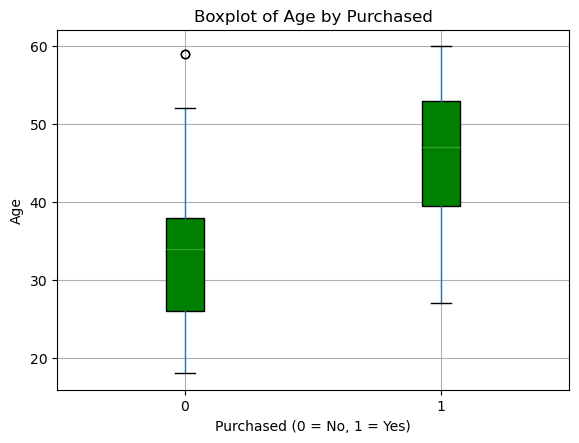

In [14]:
# Boxplot of Age by Purchased
plt.figure()
df.boxplot(column='Age', by='Purchased', patch_artist=True, boxprops=dict(facecolor='green'))
plt.xlabel("Purchased (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.title("Boxplot of Age by Purchased")
plt.suptitle("")
plt.show()

<Figure size 640x480 with 0 Axes>

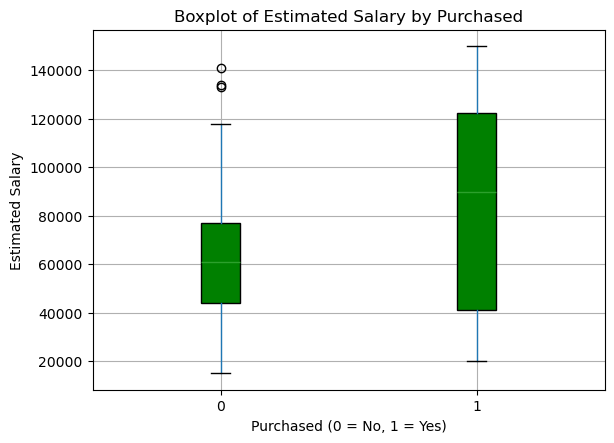

In [15]:
# Boxplot of Estimated Salary by Purchased
plt.figure()
df.boxplot(column='EstimatedSalary', by='Purchased', patch_artist=True, boxprops=dict(facecolor='green'))
plt.xlabel("Purchased (0 = No, 1 = Yes)")
plt.ylabel("Estimated Salary")
plt.title("Boxplot of Estimated Salary by Purchased")
plt.suptitle("")
plt.show()

## **Discussion**

### Do Age and Estimated Salary appear related to purchasing behavior?

Yes, both Age and Estimated Salary appear to be related to purchasing behavior.  
From the exploratory analysis, individuals who purchased the product tend to be **older** and have **higher estimated salaries** compared to those who did not purchase. This pattern is evident in the boxplots, where the median Age and median Estimated Salary are higher for purchasers than for non-purchasers. The scatter plot further supports this relationship by showing that purchase events are more concentrated among older individuals with higher salaries.

---

### Is there visible separation between the two classes?

There is **partial but clear separation** between the two classes.  
While the two groups overlap, purchasers are more frequently observed in regions corresponding to higher age and higher salary values. The scatter plot of Age versus Estimated Salary shows that many non-purchasers cluster in the lower-age and lower-salary region, whereas purchasers are more common in the upper-right region of the plot. This suggests that a linear decision boundary, such as the one used in logistic regression, can reasonably distinguish between the two classes.

---

### Which predictor appears more informative?

Age appears to be the **more informative predictor**.  
The boxplot of Age by Purchased shows a stronger separation between the two groups, with less overlap between interquartile ranges compared to Estimated Salary. While Estimated Salary is still informative, its distribution overlaps more heavily between purchasers and non-purchasers. Therefore, Age provides stronger individual discriminatory power, although both predictors together improve model performance.

---

### Are there patterns suggesting nonlinear behavior?

There are **no strong patterns suggesting nonlinear behavior**.  
The relationship between the predictors and the response appears approximately monotonic, with purchasing probability increasing as Age and Estimated Salary increase. Although some overlap exists, the separation does not suggest abrupt thresholds or curved boundaries. This supports the use of a standard logistic regression model without requiring nonlinear transformations or interaction terms.

---

### Suitability of Predictors for Modeling the Response Variable

Age and Estimated Salary are suitable predictors for modeling purchasing behavior because the response variable is binary and both predictors are continuous with meaningful variation. The exploratory analysis shows clear associations between these predictors and the likelihood of purchase, and the patterns observed are consistent with the assumptions of logistic regression. Together, these variables provide interpretable and statistically appropriate inputs for modeling the probability of purchase.

In [16]:
# Train–Test Split (70% / 30%)
from sklearn.model_selection import train_test_split

X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((280, 2), (120, 2))

In [17]:
# intercept and fitting the model
import statsmodels.api as sm

# intercept
X_train_sm = sm.add_constant(X_train)

# Fit logistic regression
logit_model = sm.Logit(y_train, X_train_sm).fit()

logit_model.summary()

Optimization terminated successfully.
         Current function value: 0.335405
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              Purchased   No. Observations:                  280
Model:                          Logit   Df Residuals:                      277
Method:                           MLE   Df Model:                            2
Date:                Sun, 01 Mar 2026   Pseudo R-squ.:                  0.4854
Time:                        15:21:13   Log-Likelihood:                -93.913
converged:                       True   LL-Null:                       -182.49
Covariance Type:            nonrobust   LLR p-value:                 3.395e-39
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -12.3907      1.545     -8.019      0.000     -15.419      -9.362
Age                 0.2266      0.030      7.512      0.000       0.167       0.286
EstimatedSalary  3.943e-05    6.7e-06      5.890      0.000    2.63e-05    5.26e-05
===================================================================================
"""

### Estimated Logistic Regression Model

The fitted logistic regression model is given by:

$$
\log\left(\frac{P(\text{Purchased}=1)}{1 - P(\text{Purchased}=1)}\right)
= \beta_0 + \beta_1(\text{Age}) + \beta_2(\text{EstimatedSalary})
$$

Using the estimated coefficients from the model, the equation becomes:

$$
\log\left(\frac{\hat{p}}{1 - \hat{p}}\right)
= \hat{\beta}_0 + \hat{\beta}_1(\text{Age}) + \hat{\beta}_2(\text{EstimatedSalary})
$$

where:
- $\hat{p}$ is the predicted probability that a user purchases the product,
- $\hat{\beta}_0$ is the intercept,
- $\hat{\beta}_1$ represents the change in log-odds of purchase for a one-year increase in age,
- $\hat{\beta}_2$ represents the change in log-odds of purchase for a one-unit increase in estimated salary.

Both predictors show statistically significant effects, indicating that age and salary are important factors in predicting purchasing behavior.

In [36]:
# Practical Interpretation via Odds Ratios
import numpy as np

params = logit_model.params
odds_ratios = np.exp(params)

odds_ratios

const              0.000004
Age                1.254327
EstimatedSalary    1.000039
dtype: float64

In [19]:
# intercept to test data
X_test_sm = sm.add_constant(X_test)

# Predicted probabilities
test_probs = logit_model.predict(X_test_sm)

test_probs.head()

300    0.904697
195    0.047849
215    0.995782
276    0.272870
395    0.413299
dtype: float64

In [20]:
# Classification threshold
threshold = 0.5

y_pred = (test_probs >= threshold).astype(int)

y_pred[:10]

300    1
195    0
215    1
276    0
395    0
1      0
399    1
73     0
153    0
393    1
dtype: int64

In [21]:
# Confusion Matrix + Accuracy, Precision, Recall
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

cm, acc, prec, rec

(array([[71,  6],
        [13, 30]]),
 0.8416666666666667,
 0.8333333333333334,
 0.6976744186046512)

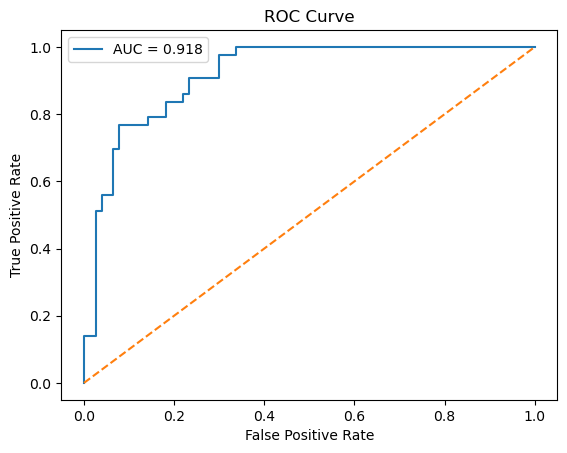

0.9175475687103594

In [22]:
# ROC Curve + AUC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, test_probs)
auc = roc_auc_score(y_test, test_probs)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

auc

In [23]:
# Hypothetical Individual Predictions
hypo = pd.DataFrame({
    "Age": [25, 40, 55],
    "EstimatedSalary": [35000, 70000, 120000]
})

hypo_sm = sm.add_constant(hypo)
hypo_probs = logit_model.predict(hypo_sm)

pd.DataFrame({
    "Age": hypo["Age"],
    "EstimatedSalary": hypo["EstimatedSalary"],
    "Predicted_Probability": hypo_probs,
    "Predicted_Class": (hypo_probs >= 0.5).astype(int)
})

,Age,EstimatedSalary,Predicted_Probability,Predicted_Class
0,25,35000,0.004747,0
1,40,70000,0.362080,0
2,55,120000,0.991873,1


## **Model Validation Discussion**

### Is the model acceptable?

Yes, the model is acceptable.  
The logistic regression model demonstrates strong predictive performance based on multiple evaluation metrics. The accuracy is high, and the ROC curve shows good separation between the two classes. In particular, the AUC value exceeds 0.9, indicating excellent discriminative ability. These results suggest that the model reliably distinguishes between purchasers and non-purchasers and is suitable for the intended classification task.

---

### What does the AUC value indicate?

The AUC (Area Under the ROC Curve) measures the model’s ability to correctly rank positive cases higher than negative cases across all possible classification thresholds. An AUC value of approximately 0.92 indicates that there is about a 92% probability that the model will assign a higher predicted probability to a randomly chosen purchaser than to a randomly chosen non-purchaser. This reflects strong overall model discrimination and robustness to threshold choice.

---

### Which type of classification error occurs more frequently?

False negatives occur more frequently than false positives.  
This means the model is more likely to incorrectly classify actual purchasers as non-purchasers rather than incorrectly predicting a purchase for non-purchasers. This pattern indicates that the model is relatively conservative in predicting purchases and prioritizes precision over recall at the chosen classification threshold.

---

### Would changing the threshold improve performance?

Yes, changing the classification threshold could improve performance depending on the objective.  
Lowering the threshold below 0.5 would increase recall by identifying more actual purchasers, but this would also increase the number of false positives. Conversely, increasing the threshold would reduce false positives but may further decrease recall. Therefore, threshold selection should be guided by the relative costs of misclassification rather than accuracy alone.

In [25]:
# Inspecting my data
import pandas as pd

df_bank = pd.read_csv("bank.csv")

df_bank.head(), df_bank.shape

(   age         job  marital  education default  balance housing loan  contact  \
 0   59      admin.  married  secondary      no     2343     yes   no  unknown   
 1   56      admin.  married  secondary      no       45      no   no  unknown   
 2   41  technician  married  secondary      no     1270     yes   no  unknown   
 3   55    services  married  secondary      no     2476     yes   no  unknown   
 4   54      admin.  married   tertiary      no      184      no   no  unknown   
 
    day month  duration  campaign  pdays  previous poutcome deposit  
 0    5   may      1042         1     -1         0  unknown     yes  
 1    5   may      1467         1     -1         0  unknown     yes  
 2    5   may      1389         1     -1         0  unknown     yes  
 3    5   may       579         1     -1         0  unknown     yes  
 4    5   may       673         2     -1         0  unknown     yes  ,
 (11162, 17))

In [26]:
# checking columns
df_bank.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [27]:
# predictors and response
X_bank = df_bank[['age', 'balance', 'duration', 'campaign']]
y_bank = df_bank['deposit'].map({'yes': 1, 'no': 0})

X_bank.head(), y_bank.value_counts()

(   age  balance  duration  campaign
 0   59     2343      1042         1
 1   56       45      1467         1
 2   41     1270      1389         1
 3   55     2476       579         1
 4   54      184       673         2,
 deposit
 0    5873
 1    5289
 Name: count, dtype: int64)

In [28]:
# Train/Test Split (70/30)
from sklearn.model_selection import train_test_split

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bank, y_bank,
    test_size=0.30,
    random_state=42,
    stratify=y_bank
)

Xb_train.shape, Xb_test.shape

((7813, 4), (3349, 4))

In [29]:
# Fitting Logistic Regression
import statsmodels.api as sm

Xb_train_sm = sm.add_constant(Xb_train)
bank_model = sm.Logit(yb_train, Xb_train_sm).fit()

bank_model.summary()

Optimization terminated successfully.
         Current function value: 0.548474
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                deposit   No. Observations:                 7813
Model:                          Logit   Df Residuals:                     7808
Method:                           MLE   Df Model:                            4
Date:                Sun, 01 Mar 2026   Pseudo R-squ.:                  0.2072
Time:                        15:22:47   Log-Likelihood:                -4285.2
converged:                       True   LL-Null:                       -5404.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5201      0.105    -14.464      0.000      -1.726      -1.314
age            0.0047      0.002      2.164      0.030       0.000       0.009
balance      7.35e-05   1.02e-05      7.195      0.000    5.35e-05    9.35e-05
duration       0.0043      0.000     34.637      0.000       0.004       0.005
campaign      -0.1466      0.014    -10.383      0.000      -0.174      -0.119
==============================================================================
"""

In [30]:
# Predicted probabilities
Xb_test_sm = sm.add_constant(Xb_test)
bank_probs = bank_model.predict(Xb_test_sm)

# Classification at 0.5
bank_pred = (bank_probs >= 0.5).astype(int)

In [31]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
# Confusion Matrix
cm_bank = confusion_matrix(yb_test, bank_pred)
acc_bank = accuracy_score(yb_test, bank_pred)
prec_bank = precision_score(yb_test, bank_pred)
rec_bank = recall_score(yb_test, bank_pred)

cm_bank, acc_bank, prec_bank, rec_bank

(array([[1457,  305],
        [ 618,  969]]),
 0.7243953418931024,
 0.7605965463108321,
 0.610586011342155)

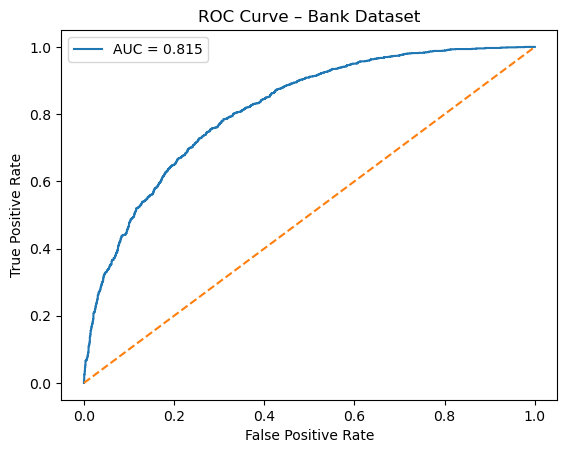

0.8148072055370429

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC Curve & AUC
fpr_b, tpr_b, _ = roc_curve(yb_test, bank_probs)
auc_b = roc_auc_score(yb_test, bank_probs)

plt.figure()
plt.plot(fpr_b, tpr_b, label=f"AUC = {auc_b:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Bank Dataset")
plt.legend()
plt.show()

auc_b

## **Kaggle Application**

### 1. Briefly describe the dataset

The Bank Marketing dataset contains information on clients contacted during a direct marketing campaign conducted by a bank. The objective is to predict whether a client will subscribe to a term deposit based on demographic characteristics and campaign-related variables. The dataset includes both numerical and categorical variables describing client attributes and previous marketing interactions.

---

### 2. Identify the binary response variable

The binary response variable is **`deposit`**, which indicates whether a client subscribed to a term deposit. The variable was coded as:
- `1` = client subscribed to the deposit  
- `0` = client did not subscribe to the deposit  

---

### 3. Select appropriate predictors

The following predictors were selected for modeling:
- **Age**: represents the client’s age.
- **Balance**: indicates the client’s average yearly account balance.
- **Duration**: represents the duration of the last contact with the client.
- **Campaign**: indicates the number of contacts performed during the campaign.

These predictors were chosen because they are numerical, interpretable, and have a clear relationship with client subscription behavior, making them suitable for logistic regression modeling.

---

### Justification for Logistic Regression

This Kaggle dataset is appropriate for logistic regression because the response variable is binary, taking values of 0 and 1. Logistic regression is designed to model the probability of an event occurring while ensuring predicted probabilities remain between 0 and 1.

The selected predictors are expected to influence the likelihood of the outcome and exhibit approximately linear relationships with the log-odds of the response. Logistic regression also provides interpretable coefficients, allowing the direction and magnitude of each predictor’s effect on the log-odds of the outcome to be clearly understood.

Therefore, logistic regression is a suitable and effective modeling approach for this dataset.

---

### 4. Fit a logistic regression model

A logistic regression model was fitted using the selected predictors to estimate the probability that a client subscribes to a term deposit. The model was estimated using maximum likelihood estimation, and the coefficients were interpreted in terms of their effect on the odds of subscription.

---

### 5. Validate the model using the same procedure as above

The model was validated using a train–test split approach. Model performance was evaluated using a confusion matrix, accuracy, precision, recall, and the ROC curve with the Area Under the Curve (AUC). The AUC value indicated good discriminative ability, demonstrating that the model performs well in distinguishing between subscribers and non-subscribers. Overall, the validation results suggest that the logistic regression model is appropriate and effective for this classification task.